In [86]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [87]:
# ── 通道定義 & 五腦區分組 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',   # 0-6
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7', # 7-14
    'O1','Oz','O2',                              # 15-17
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8', # 18-25
    'FT10','FC6','FC2','F4','F8','Fp2'           # 26-31
]

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],
    'Central':   [7, 24, 23, 6, 28, 5, 27],
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],
    'Temporal':  [8, 25, 4, 26, 9, 20],
    'Occipital': [15, 17, 16],
}

BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CLASS_NAMES = ['amateur', 'master', 'prof']

In [88]:
# ── PLV 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_plv(filepath):
    with h5py.File(filepath, 'r') as f:
        rm = f['result_mats']
        bands_data = []
        for band in BAND_NAMES:
            bands_data.append(np.array(rm[band]))
    return np.array(bands_data)  # (5, 200, 32, 32)

def load_plv_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_plv(ss01_map[sub_id]))
        X2.append(load_plv(ss02_map[sub_id]))
        X3.append(load_plv(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data  # (32ch, 39time, 5bands)

def load_be_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

# PLV paths
BASE_PLV = {
    'amateur': r'D:\Tseng\圍棋\amateur\PLV_Results_2026',
    'master':  r'D:\Tseng\圍棋\master\PLV_Results_2026',
    'prof':    r'D:\Tseng\圍棋\prof\PLV_Results_2026',
}
# Band Energy paths
BASE_BE = {
    'amateur': r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026',
    'master':  r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026',
    'prof':    r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026',
}

# 載入 PLV
plv_maps, complete = {}, {}
for group in CLASS_NAMES:
    paths = {s: os.path.join(BASE_PLV[group], s) for s in ['ss01','ss02','ss03']}
    m1, m2, m3 = scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03'])
    plv_maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] 完整 subject：{len(complete[group])} 人')

print('\n載入 PLV 資料...')
X_a1, X_a2, X_a3 = load_plv_group(*plv_maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_plv_group(*plv_maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_plv_group(*plv_maps['prof'],    complete['prof'])
print(f'PLV shape: {X_a1.shape},{X_m1.shape},{X_p1.shape}')

# 載入 Band Energy
print('\n載入 Band Energy 資料...')
be_maps = {}
for group in CLASS_NAMES:
    paths = {s: os.path.join(BASE_BE[group], s) for s in ['ss01','ss02','ss03']}
    be_maps[group] = (scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03']))

BE_a1, BE_a2, BE_a3 = load_be_group(*be_maps['amateur'], complete['amateur'])
BE_m1, BE_m2, BE_m3 = load_be_group(*be_maps['master'],  complete['master'])
BE_p1, BE_p2, BE_p3 = load_be_group(*be_maps['prof'],    complete['prof'])
print(f'BE shape:  {BE_a1.shape}')


[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入 PLV 資料...
PLV shape: (28, 5, 200, 32, 32),(20, 5, 200, 32, 32),(8, 5, 200, 32, 32)

載入 Band Energy 資料...
BE shape:  (28, 32, 39, 5)


In [89]:
# ── 特徵提取 & 標籤準備 ──

triu_idx = np.triu_indices(32, k=1)

def extract_plv_features(X, ch_idx=None):
    X_mean = X.mean(axis=2)
    if ch_idx is not None:
        X_mean = X_mean[:, :, np.ix_(ch_idx, ch_idx)[0], np.ix_(ch_idx, ch_idx)[1]]
        n_ch = len(ch_idx)
        tri = np.triu_indices(n_ch, k=1)
    else:
        tri = triu_idx
    feats = []
    for b in range(5):
        feats.append(X_mean[:, b, tri[0], tri[1]])
    return np.hstack(feats)

def extract_be_features(X_be, ch_idx=None):
    X = np.log(X_be + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    if ch_idx is not None:
        X = X[:, ch_idx, :]
    return X.reshape(len(X), -1)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])

# PLV: group-then-session
plv_all = []
for g in CLASS_NAMES:
    for Xr in [{'amateur': [X_a1,X_a2,X_a3], 'master': [X_m1,X_m2,X_m3], 'prof': [X_p1,X_p2,X_p3]}[g]]:
        for x in Xr:
            plv_all.append(x)
X_plv = np.vstack(plv_all)  # (168, 5, 200, 32, 32)

# BE: group-then-session
be_all = []
for g in CLASS_NAMES:
    for Xr in [{'amateur': [BE_a1,BE_a2,BE_a3], 'master': [BE_m1,BE_m2,BE_m3], 'prof': [BE_p1,BE_p2,BE_p3]}[g]]:
        for x in Xr:
            be_all.append(x)
X_be = np.vstack(be_all)  # (168, 32, 39, 5)

y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_m * 3), np.full(n_p * 3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_plv: {X_plv.shape}  X_be: {X_be.shape}  y: {y_all.shape}')


X_plv: (168, 5, 200, 32, 32)  X_be: (168, 32, 39, 5)  y: (168,)


In [90]:
# ── PLV + BE 分開 PCA（95% 解釋變異）再合併 LOSO ──

def run_loso_combined(X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
                      pca_variance=0.95):
    feat_plv = extract_plv_features(X_plv, ch_idx)
    feat_be  = extract_be_features(X_be, ch_idx)

    dims_plv = feat_plv.shape[1]
    dims_be  = feat_be.shape[1]

    all_preds, all_true, all_proba = [], [], []
    per_sub = []
    pca_plv_dims_list = []
    pca_be_dims_list = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        y_tr = y_all[train_mask].astype(int)
        y_te = y_all[test_mask].astype(int)

        # PLV branch: scale -> PCA(95%)
        plv_tr, plv_te = feat_plv[train_mask], feat_plv[test_mask]
        scaler_plv = StandardScaler()
        plv_tr = scaler_plv.fit_transform(plv_tr)
        plv_te = scaler_plv.transform(plv_te)
        pca_plv_obj = PCA(n_components=pca_variance)
        plv_tr = pca_plv_obj.fit_transform(plv_tr)
        plv_te = pca_plv_obj.transform(plv_te)
        pca_plv_dims_list.append(pca_plv_obj.n_components_)

        # BE branch: scale -> PCA(95%)
        be_tr, be_te = feat_be[train_mask], feat_be[test_mask]
        scaler_be = StandardScaler()
        be_tr = scaler_be.fit_transform(be_tr)
        be_te = scaler_be.transform(be_te)
        pca_be_obj = PCA(n_components=pca_variance)
        be_tr = pca_be_obj.fit_transform(be_tr)
        be_te = pca_be_obj.transform(be_te)
        pca_be_dims_list.append(pca_be_obj.n_components_)

        # 合併 PCA 後的特徵
        X_tr = np.hstack([plv_tr, be_tr])
        X_te = np.hstack([plv_te, be_te])

        # concat 後再做一次 StandardScaler：讓 PLV/BE 的每個 PC 在 SVM 距離計算中權重一致
        scaler_final = StandardScaler()
        X_tr = scaler_final.fit_transform(X_tr)
        X_te = scaler_final.transform(X_te)

        clf = SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42,
                  probability=True)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        proba = clf.predict_proba(X_te)  # (3, 3) for 3 sessions

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)
        all_proba.extend(proba)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    all_proba = np.array(all_proba)  # (168, 3)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
    dims = dims_plv + dims_be
    # 取各 fold 的中位數作為代表 PCA 維度
    pca_plv_n = int(np.median(pca_plv_dims_list))
    pca_be_n  = int(np.median(pca_be_dims_list))
    pca_n = pca_plv_n + pca_be_n
    return mean_acc, mean_f1, per_sub, all_preds, all_true, all_proba, dims, pca_n, pca_plv_n, pca_be_n

# ── 五腦區 LOSO ──
combined_results = {}

for region_name, ch_idx in REGIONS.items():
    n_ch = len(ch_idx)
    acc, f1, per_sub, preds, true, proba, dims, pca_n, pca_plv_n, pca_be_n = run_loso_combined(
        X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
        pca_variance=0.95
    )
    n_plv = len(np.triu_indices(n_ch, k=1)[0]) * 5
    n_be  = n_ch * 5
    combined_results[region_name] = {
        'acc': acc, 'f1': f1, 'dims': dims, 'pca': pca_n,
        'preds': preds, 'true': true, 'proba': proba, 'per_sub': per_sub,
        'ch_idx': ch_idx, 'pca_plv_n': pca_plv_n, 'pca_be_n': pca_be_n,
    }
    print(f'[{region_name:<10s}] PLV={n_plv:3d}(95%→{pca_plv_n:2d}) + BE={n_be:2d}(95%→{pca_be_n:2d}) = {dims:4d} dims  '
          f'PCA total={pca_n:2d}  Acc={acc:.3f}  F1={f1:.3f}')

[Frontal   ] PLV=105(95%→16) + BE=35(95%→ 7) =  140 dims  PCA total=23  Acc=0.708  F1=0.672
[Central   ] PLV=105(95%→19) + BE=35(95%→ 8) =  140 dims  PCA total=27  Acc=0.744  F1=0.755
[Parietal  ] PLV=180(95%→21) + BE=45(95%→ 7) =  225 dims  PCA total=28  Acc=0.839  F1=0.838
[Temporal  ] PLV= 75(95%→10) + BE=30(95%→ 6) =  105 dims  PCA total=16  Acc=0.619  F1=0.584
[Occipital ] PLV= 15(95%→ 4) + BE=15(95%→ 4) =   30 dims  PCA total= 8  Acc=0.536  F1=0.530


Band Energy vs PLV vs Combined (PLV+BE) — SVM 3-Class LOSO
Region         BE Acc  PLV Acc  Comb Acc    BE F1   PLV F1   Comb F1
------------------------------------------------------------------------------------------
Frontal         0.643    0.536     0.708    0.615    0.491     0.672
Central         0.601    0.583     0.744    0.575    0.526     0.755
Parietal        0.708    0.738     0.839    0.691    0.736     0.838
Temporal        0.577    0.506     0.619    0.555    0.468     0.584
Occipital       0.500    0.446     0.536    0.492    0.444     0.530


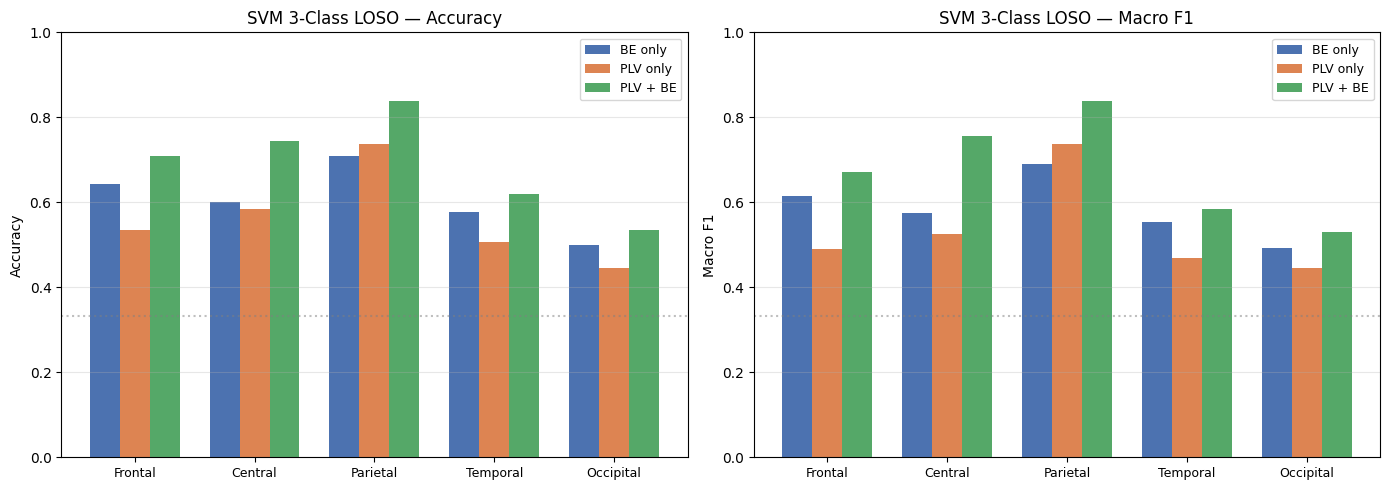

In [91]:
# ── 三方比較表：BE vs PLV vs Combined ──

import json

# 從 svm_band_energy.ipynb 與 svm_plv.ipynb 的輸出 JSON 讀回結果
# (記得先跑過那兩個 notebook 才會有檔案)
with open(r'D:\Tseng\game_eeg\SVM_BE\svm_band_energy_results.json', 'r', encoding='utf-8') as _f:
    be_results = json.load(_f)
with open(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_results.json', 'r', encoding='utf-8') as _f:
    plv_results = json.load(_f)

print('=' * 90)
print('Band Energy vs PLV vs Combined (PLV+BE) \u2014 SVM 3-Class LOSO')
print('=' * 90)
print(f'{"Region":<12s} {"BE Acc":>8s} {"PLV Acc":>8s} {"Comb Acc":>9s} '
      f'{"BE F1":>8s} {"PLV F1":>8s} {"Comb F1":>9s}')
print('-' * 90)

for rn in REGIONS:
    be  = be_results[rn]
    plv = plv_results[rn]
    cmb = combined_results[rn]
    print(f'{rn:<12s} {be["acc"]:8.3f} {plv["acc"]:8.3f} {cmb["acc"]:9.3f} '
          f'{be["f1"]:8.3f} {plv["f1"]:8.3f} {cmb["f1"]:9.3f}')
print('=' * 90)

# ── Bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_names = list(REGIONS.keys())
x = np.arange(len(region_names))
width = 0.25

for ax_idx, (metric, title) in enumerate([('acc', 'Accuracy'), ('f1', 'Macro F1')]):
    ax = axes[ax_idx]
    be_vals  = [be_results[rn][metric] for rn in region_names]
    plv_vals = [plv_results[rn][metric] for rn in region_names]
    cmb_vals = [combined_results[rn][metric] for rn in region_names]

    ax.bar(x - width, be_vals,  width, label='BE only',  color='#4C72B0')
    ax.bar(x,         plv_vals, width, label='PLV only', color='#DD8452')
    ax.bar(x + width, cmb_vals, width, label='PLV + BE', color='#55A868')

    ax.set_xticks(x)
    ax.set_xticklabels(region_names, fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'SVM 3-Class LOSO \u2014 {title}')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_be_combined_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

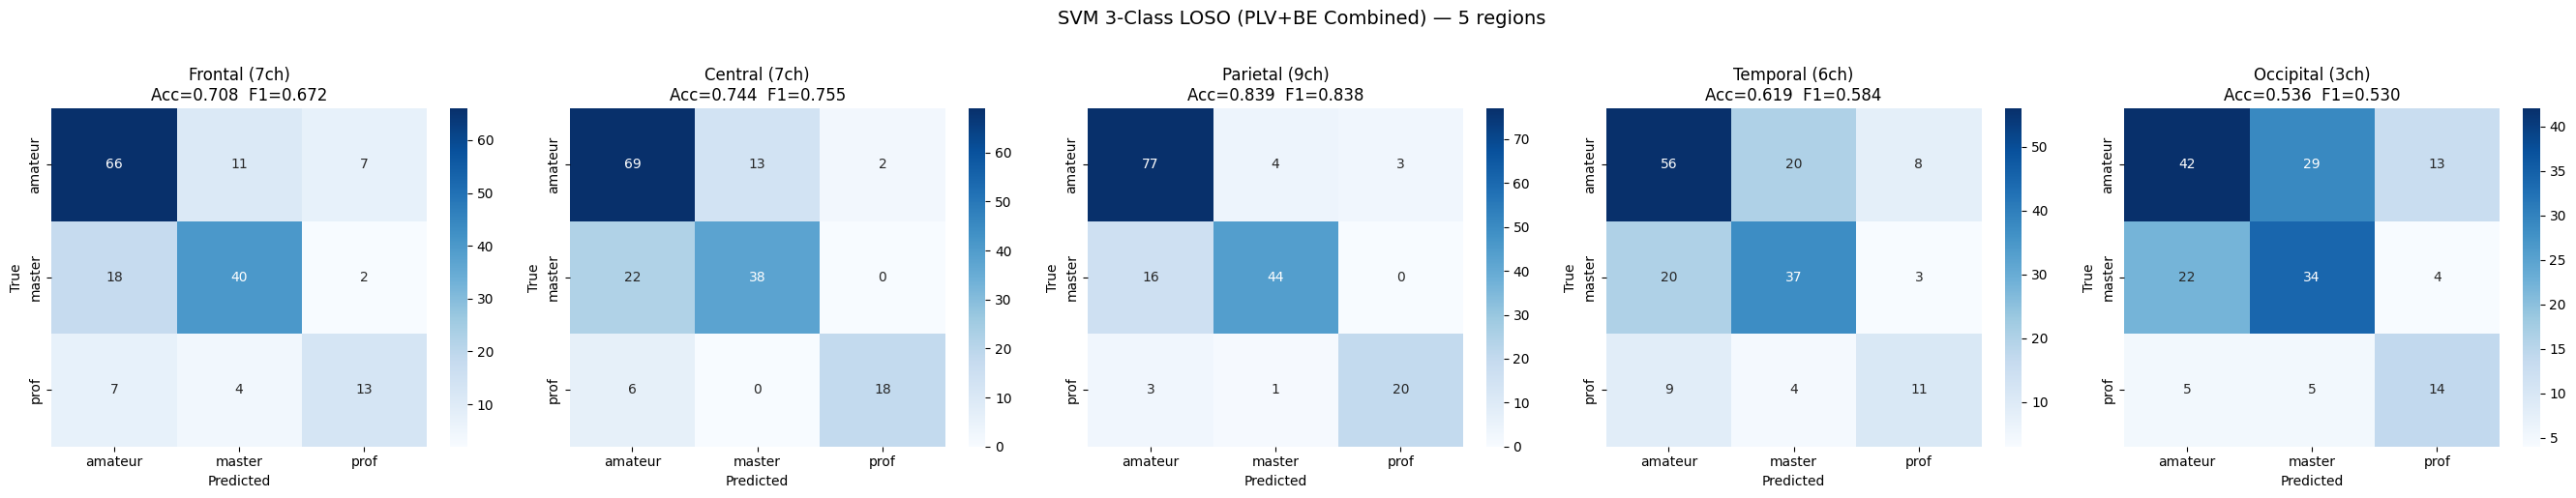

In [92]:
# ── 混淆矩陣 ──

fig, axes = plt.subplots(1, 5, figsize=(27, 5))

for ax, (region_name, r) in zip(axes, combined_results.items()):
    cm = confusion_matrix(r['true'], r['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    n_ch = len(r['ch_idx'])
    ax.set_title(f'{region_name} ({n_ch}ch)\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

plt.suptitle('SVM 3-Class LOSO (PLV+BE Combined) \u2014 5 regions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_be_combined_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [93]:
# ── 各腦區 Classification Report ──

for region_name, r in combined_results.items():
    n_ch = len(r['ch_idx'])
    print(f'\n{"="*60}')
    print(f'{region_name} ({n_ch}ch)  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}')
    print(f'{"="*60}')
    print(classification_report(r['true'], r['preds'],
                                target_names=CLASS_NAMES, zero_division=0))


Frontal (7ch)  Acc=0.708  F1=0.672
              precision    recall  f1-score   support

     amateur       0.73      0.79      0.75        84
      master       0.73      0.67      0.70        60
        prof       0.59      0.54      0.57        24

    accuracy                           0.71       168
   macro avg       0.68      0.66      0.67       168
weighted avg       0.71      0.71      0.71       168


Central (7ch)  Acc=0.744  F1=0.755
              precision    recall  f1-score   support

     amateur       0.71      0.82      0.76        84
      master       0.75      0.63      0.68        60
        prof       0.90      0.75      0.82        24

    accuracy                           0.74       168
   macro avg       0.79      0.73      0.76       168
weighted avg       0.75      0.74      0.74       168


Parietal (9ch)  Acc=0.839  F1=0.838
              precision    recall  f1-score   support

     amateur       0.80      0.92      0.86        84
      master       0

RV Coefficient Matrix: 5 regions × {PLV, BE}
  Frontal_PLV     vs Central_PLV      RV=0.284  (relatively independent)
  Frontal_PLV     vs Parietal_PLV     RV=0.136  (relatively independent)
  Frontal_PLV     vs Temporal_PLV     RV=0.202  (relatively independent)
  Frontal_PLV     vs Occipital_PLV    RV=0.034  (relatively independent)
  Frontal_PLV     vs Frontal_BE       RV=0.115  (relatively independent)
  Frontal_PLV     vs Central_BE       RV=0.084  (relatively independent)
  Frontal_PLV     vs Parietal_BE      RV=0.092  (relatively independent)
  Frontal_PLV     vs Temporal_BE      RV=0.075  (relatively independent)
  Frontal_PLV     vs Occipital_BE     RV=0.048  (relatively independent)
  Central_PLV     vs Parietal_PLV     RV=0.387  (relatively independent)
  Central_PLV     vs Temporal_PLV     RV=0.218  (relatively independent)
  Central_PLV     vs Occipital_PLV    RV=0.043  (relatively independent)
  Central_PLV     vs Frontal_BE       RV=0.158  (relatively independent)
  Cent

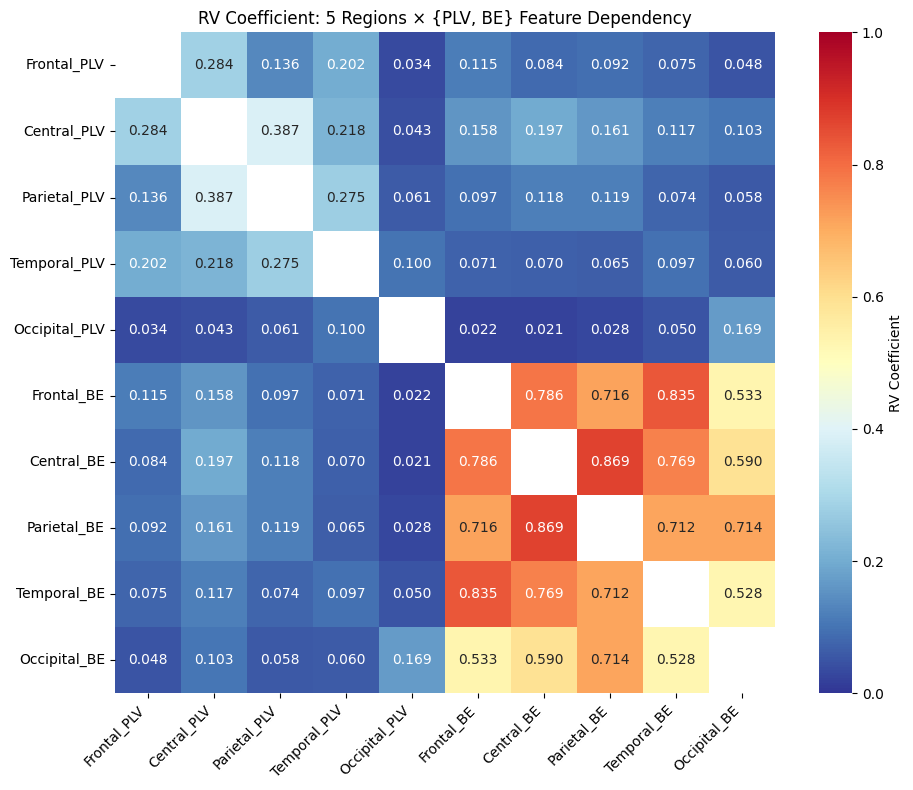

In [94]:
# ── RV Coefficient：PLV vs Band Energy 特徵相依性 ──

def rv_coefficient(X, Y):
    X_c = X - X.mean(axis=0)
    Y_c = Y - Y.mean(axis=0)
    S_XX = X_c.T @ X_c
    S_YY = Y_c.T @ Y_c
    S_XY = X_c.T @ Y_c
    num = np.trace(S_XY @ S_XY.T)
    den = np.sqrt(np.trace(S_XX @ S_XX) * np.trace(S_YY @ S_YY))
    return num / den

region_names = list(REGIONS.keys())
feature_names = [f'{rn}_PLV' for rn in region_names] + [f'{rn}_BE' for rn in region_names]
n_feat = len(feature_names)

all_feat_blocks = {}
for rn, ch_idx in REGIONS.items():
    all_feat_blocks[f'{rn}_PLV'] = extract_plv_features(X_plv, ch_idx)
    all_feat_blocks[f'{rn}_BE']  = extract_be_features(X_be, ch_idx)

rv_matrix = np.zeros((n_feat, n_feat))
for i, fi in enumerate(feature_names):
    for j, fj in enumerate(feature_names):
        rv_matrix[i, j] = rv_coefficient(all_feat_blocks[fi], all_feat_blocks[fj])

# 數值表
print('=' * 60)
print('RV Coefficient Matrix: 5 regions \u00d7 {PLV, BE}')
print('=' * 60)
for i in range(n_feat):
    for j in range(i+1, n_feat):
        rv = rv_matrix[i, j]
        if rv > 0.7:
            label = 'highly redundant'
        elif rv > 0.4:
            label = 'moderately dependent'
        else:
            label = 'relatively independent'
        print(f'  {feature_names[i]:15s} vs {feature_names[j]:15s}  RV={rv:.3f}  ({label})')
print('=' * 60)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(rv_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(rv_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            vmin=0, vmax=1, mask=mask,
            xticklabels=feature_names, yticklabels=feature_names,
            ax=ax, square=True,
            cbar_kws={'label': 'RV Coefficient'})
ax.set_title('RV Coefficient: 5 Regions \u00d7 {PLV, BE} Feature Dependency')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_plv_vs_be_rv.png',
            dpi=150, bbox_inches='tight')
plt.show()

Parietal — Hard Vote vs Soft Vote (PLV→40 + BE→20)
Subject             True    ss01    ss02    ss03    Hard    Soft      Soft Prob (am/ma/pr)   H   S
---------------------------------------------------------------------------------------------------------
sub-22           amateur amateur amateur amateur amateur amateur      [0.71 / 0.25 / 0.04]   O   O
sub-23           amateur amateur amateur amateur amateur amateur      [0.84 / 0.12 / 0.04]   O   O
sub-24           amateur  master amateur amateur amateur amateur      [0.51 / 0.44 / 0.06]   O   O
sub-33           amateur amateur amateur amateur amateur amateur      [0.72 / 0.18 / 0.10]   O   O
sub-38           amateur amateur amateur amateur amateur amateur      [0.78 / 0.19 / 0.03]   O   O
sub-39           amateur amateur amateur amateur amateur amateur      [0.82 / 0.15 / 0.03]   O   O
sub-40           amateur amateur amateur amateur amateur amateur      [0.76 / 0.18 / 0.05]   O   O
sub-41           amateur amateur amateur    prof am

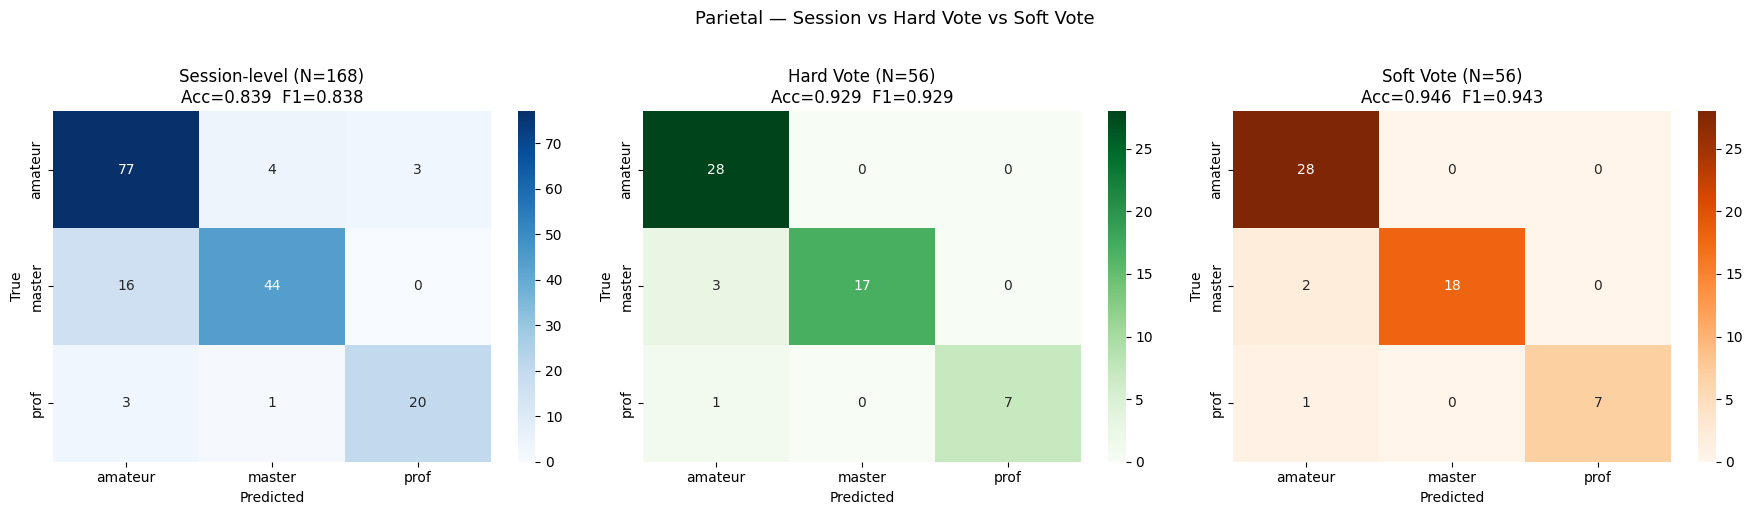

In [95]:
# ── Parietal 多數決分析：硬投票 vs 軟投票 ──
from scipy import stats

r = combined_results['Parietal']
preds_all = r['preds']
true_all  = r['true']
proba_all = r['proba']   # (168, 3)

print('=' * 105)
print('Parietal — Hard Vote vs Soft Vote (PLV→40 + BE→20)')
print('=' * 105)
print(f'{"Subject":<15s} {"True":>8s} {"ss01":>7s} {"ss02":>7s} {"ss03":>7s} '
      f'{"Hard":>7s} {"Soft":>7s} {"Soft Prob (am/ma/pr)":>25s} {"H":>3s} {"S":>3s}')
print('-' * 105)

hard_preds, soft_preds, vote_true = [], [], []

for i, sub_id in enumerate(subject_ids):
    true_label = subject_labels[sub_id]
    idx = slice(i*3, i*3+3)
    p1, p2, p3 = preds_all[i*3], preds_all[i*3+1], preds_all[i*3+2]

    # Hard vote: 多數決
    hard = int(stats.mode([p1, p2, p3], keepdims=False).mode)

    # Soft vote: 3 session 機率平均後取 argmax
    mean_proba = proba_all[idx].mean(axis=0)  # (3,)
    soft = int(np.argmax(mean_proba))

    hard_preds.append(hard)
    soft_preds.append(soft)
    vote_true.append(true_label)

    h_mark = 'O' if hard == true_label else 'X'
    s_mark = 'O' if soft == true_label else 'X'
    prob_str = f'[{mean_proba[0]:.2f} / {mean_proba[1]:.2f} / {mean_proba[2]:.2f}]'

    print(f'{sub_id:<15s} {CLASS_NAMES[true_label]:>8s} '
          f'{CLASS_NAMES[int(p1)]:>7s} {CLASS_NAMES[int(p2)]:>7s} {CLASS_NAMES[int(p3)]:>7s} '
          f'{CLASS_NAMES[hard]:>7s} {CLASS_NAMES[soft]:>7s} {prob_str:>25s} {h_mark:>3s} {s_mark:>3s}')

hard_preds = np.array(hard_preds)
soft_preds = np.array(soft_preds)
vote_true  = np.array(vote_true)

# Metrics
hard_acc = accuracy_score(vote_true, hard_preds)
hard_f1  = f1_score(vote_true, hard_preds, average='macro', zero_division=0)
soft_acc = accuracy_score(vote_true, soft_preds)
soft_f1  = f1_score(vote_true, soft_preds, average='macro', zero_division=0)

print('=' * 105)
print(f'\nSession-level:  Acc = {r["acc"]:.3f}   F1 = {r["f1"]:.3f}   (N = {len(preds_all)} samples)')
print(f'Hard Vote:      Acc = {hard_acc:.3f}   F1 = {hard_f1:.3f}   (N = {len(hard_preds)} subjects)')
print(f'Soft Vote:      Acc = {soft_acc:.3f}   F1 = {soft_f1:.3f}   (N = {len(soft_preds)} subjects)')

# 差異分析
diff_mask = hard_preds != soft_preds
n_diff = diff_mask.sum()
print(f'\n硬投票 vs 軟投票不一致: {n_diff} / {len(hard_preds)} subjects')
for i, sub_id in enumerate(subject_ids):
    if diff_mask[i]:
        true_g = CLASS_NAMES[vote_true[i]]
        hard_g = CLASS_NAMES[hard_preds[i]]
        soft_g = CLASS_NAMES[soft_preds[i]]
        h_ok = 'O' if hard_preds[i] == vote_true[i] else 'X'
        s_ok = 'O' if soft_preds[i] == vote_true[i] else 'X'
        print(f'  {sub_id:<15s} true={true_g:<8s} hard={hard_g}({h_ok})  soft={soft_g}({s_ok})')

# Classification Reports
for name, preds in [('Hard Vote', hard_preds), ('Soft Vote', soft_preds)]:
    print(f'\n{"="*60}')
    print(f'Parietal — {name} Classification Report')
    print(f'{"="*60}')
    print(classification_report(vote_true, preds,
                                target_names=CLASS_NAMES, zero_division=0))

# 混淆矩陣: Session / Hard / Soft
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_session = confusion_matrix(true_all, preds_all, labels=[0, 1, 2])
sns.heatmap(cm_session, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Session-level (N={len(preds_all)})\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

cm_hard = confusion_matrix(vote_true, hard_preds, labels=[0, 1, 2])
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title(f'Hard Vote (N={len(hard_preds)})\nAcc={hard_acc:.3f}  F1={hard_f1:.3f}')

cm_soft = confusion_matrix(vote_true, soft_preds, labels=[0, 1, 2])
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
axes[2].set_title(f'Soft Vote (N={len(soft_preds)})\nAcc={soft_acc:.3f}  F1={soft_f1:.3f}')

plt.suptitle('Parietal — Session vs Hard Vote vs Soft Vote', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_parietal_majority_vote.png',
            dpi=150, bbox_inches='tight')
plt.show()

PLV PCA: 21 dims, BE PCA: 7 dims, Total: 28 dims


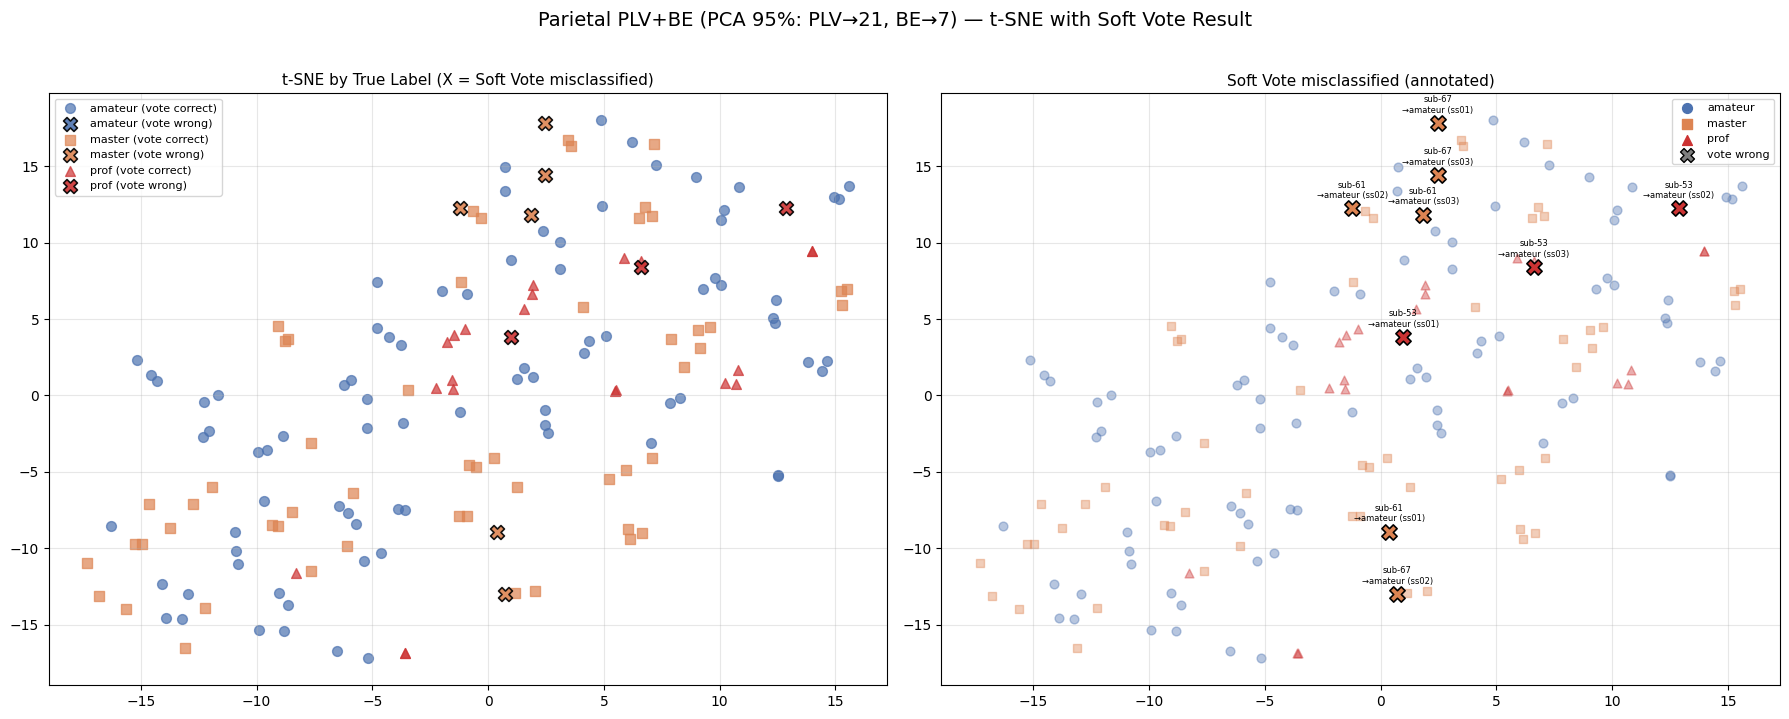


Soft Vote 分錯: 3 / 56 subjects
  sub-61          true=master   vote=amateur  prob=[0.50/0.49/0.01]
  sub-67          true=master   vote=amateur  prob=[0.56/0.42/0.02]
  sub-53          true=prof     vote=amateur  prob=[0.41/0.30/0.29]


In [96]:
# ── Parietal 2D t-SNE：以 Soft Vote 結果標記 ──
from sklearn.manifold import TSNE

ch_idx = REGIONS['Parietal']
feat_plv = extract_plv_features(X_plv, ch_idx)
feat_be  = extract_be_features(X_be, ch_idx)

scaler_plv = StandardScaler()
plv_scaled = scaler_plv.fit_transform(feat_plv)
pca_plv_obj = PCA(n_components=0.95)
plv_pca = pca_plv_obj.fit_transform(plv_scaled)

scaler_be = StandardScaler()
be_scaled = scaler_be.fit_transform(feat_be)
pca_be_obj = PCA(n_components=0.95)
be_pca = pca_be_obj.fit_transform(be_scaled)

X_combined = np.hstack([plv_pca, be_pca])
print(f'PLV PCA: {plv_pca.shape[1]} dims, BE PCA: {be_pca.shape[1]} dims, Total: {X_combined.shape[1]} dims')

# 2D t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=2000)
X_tsne = tsne.fit_transform(X_combined)

# 預測結果
r = combined_results['Parietal']
preds = r['preds']
true  = r['true']
proba_all = r['proba']

# 建立 sample info
sample_subs = []
for g in CLASS_NAMES:
    for sub_id in complete[g]:
        for ss in [1, 2, 3]:
            sample_subs.append(sub_id)
sample_subs = np.array(sample_subs)

# Soft vote 結果
mv_correct = {}
mv_pred_label = {}
for i, sub_id in enumerate(subject_ids):
    mean_proba = proba_all[i*3:i*3+3].mean(axis=0)
    mv_pred = int(np.argmax(mean_proba))
    mv_correct[sub_id] = (mv_pred == subject_labels[sub_id])
    mv_pred_label[sub_id] = mv_pred

# 每筆 sample 的 soft vote 正確/錯誤
mv_mask = np.array([mv_correct[s] for s in sample_subs])

group_colors = {'amateur': '#4C72B0', 'master': '#DD8452', 'prof': '#CC3333'}
group_markers = {'amateur': 'o', 'master': 's', 'prof': '^'}

pca_plv_n = combined_results['Parietal']['pca_plv_n']
pca_be_n = combined_results['Parietal']['pca_be_n']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 左圖: 按 true label 上色，soft vote 分錯的人用 X 標記
ax = axes[0]
for g_idx, g in enumerate(CLASS_NAMES):
    mask_g = (true == g_idx)
    mask_correct = mask_g & mv_mask
    ax.scatter(X_tsne[mask_correct, 0], X_tsne[mask_correct, 1],
               c=group_colors[g], marker=group_markers[g], s=50, alpha=0.7,
               label=f'{g} (vote correct)')
    mask_wrong = mask_g & ~mv_mask
    ax.scatter(X_tsne[mask_wrong, 0], X_tsne[mask_wrong, 1],
               c=group_colors[g], marker='X', s=100, alpha=0.9, edgecolors='black', linewidths=1.2,
               label=f'{g} (vote wrong)')

ax.set_title('t-SNE by True Label (X = Soft Vote misclassified)', fontsize=11)
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3)

# 右圖: 分錯的標註 subject ID 和被誤判成什麼
ax = axes[1]
for g_idx, g in enumerate(CLASS_NAMES):
    mask_g = (true == g_idx)
    mask_correct = mask_g & mv_mask
    ax.scatter(X_tsne[mask_correct, 0], X_tsne[mask_correct, 1],
               c=group_colors[g], marker=group_markers[g], s=40, alpha=0.4)

for i in range(len(true)):
    if not mv_mask[i]:
        true_g = CLASS_NAMES[int(true[i])]
        pred_g = CLASS_NAMES[mv_pred_label[sample_subs[i]]]
        ax.scatter(X_tsne[i, 0], X_tsne[i, 1],
                   c=group_colors[true_g], marker='X', s=120,
                   edgecolors='black', linewidths=1.2, zorder=5)
        ss_num = (i % 3) + 1
        ax.annotate(f'{sample_subs[i]}\n→{pred_g} (ss0{ss_num})',
                    (X_tsne[i, 0], X_tsne[i, 1]),
                    fontsize=6, ha='center', va='bottom',
                    textcoords='offset points', xytext=(0, 6))

ax.set_title('Soft Vote misclassified (annotated)', fontsize=11)
ax.grid(alpha=0.3)
for g in CLASS_NAMES:
    ax.scatter([], [], c=group_colors[g], marker=group_markers[g], s=50, label=g)
ax.scatter([], [], c='gray', marker='X', s=100, edgecolors='black', label='vote wrong')
ax.legend(fontsize=8, loc='best')

plt.suptitle(f'Parietal PLV+BE (PCA 95%: PLV→{pca_plv_n}, BE→{pca_be_n}) — t-SNE with Soft Vote Result', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_parietal_tsne.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 統計
n_wrong = sum(not v for v in mv_correct.values())
print(f'\nSoft Vote 分錯: {n_wrong} / {len(mv_correct)} subjects')
for sub_id, correct in mv_correct.items():
    if not correct:
        true_g = CLASS_NAMES[subject_labels[sub_id]]
        i = subject_ids.index(sub_id)
        mean_proba = proba_all[i*3:i*3+3].mean(axis=0)
        mv_pred = CLASS_NAMES[int(np.argmax(mean_proba))]
        print(f'  {sub_id:<15s} true={true_g:<8s} vote={mv_pred:<8s} prob=[{mean_proba[0]:.2f}/{mean_proba[1]:.2f}/{mean_proba[2]:.2f}]')

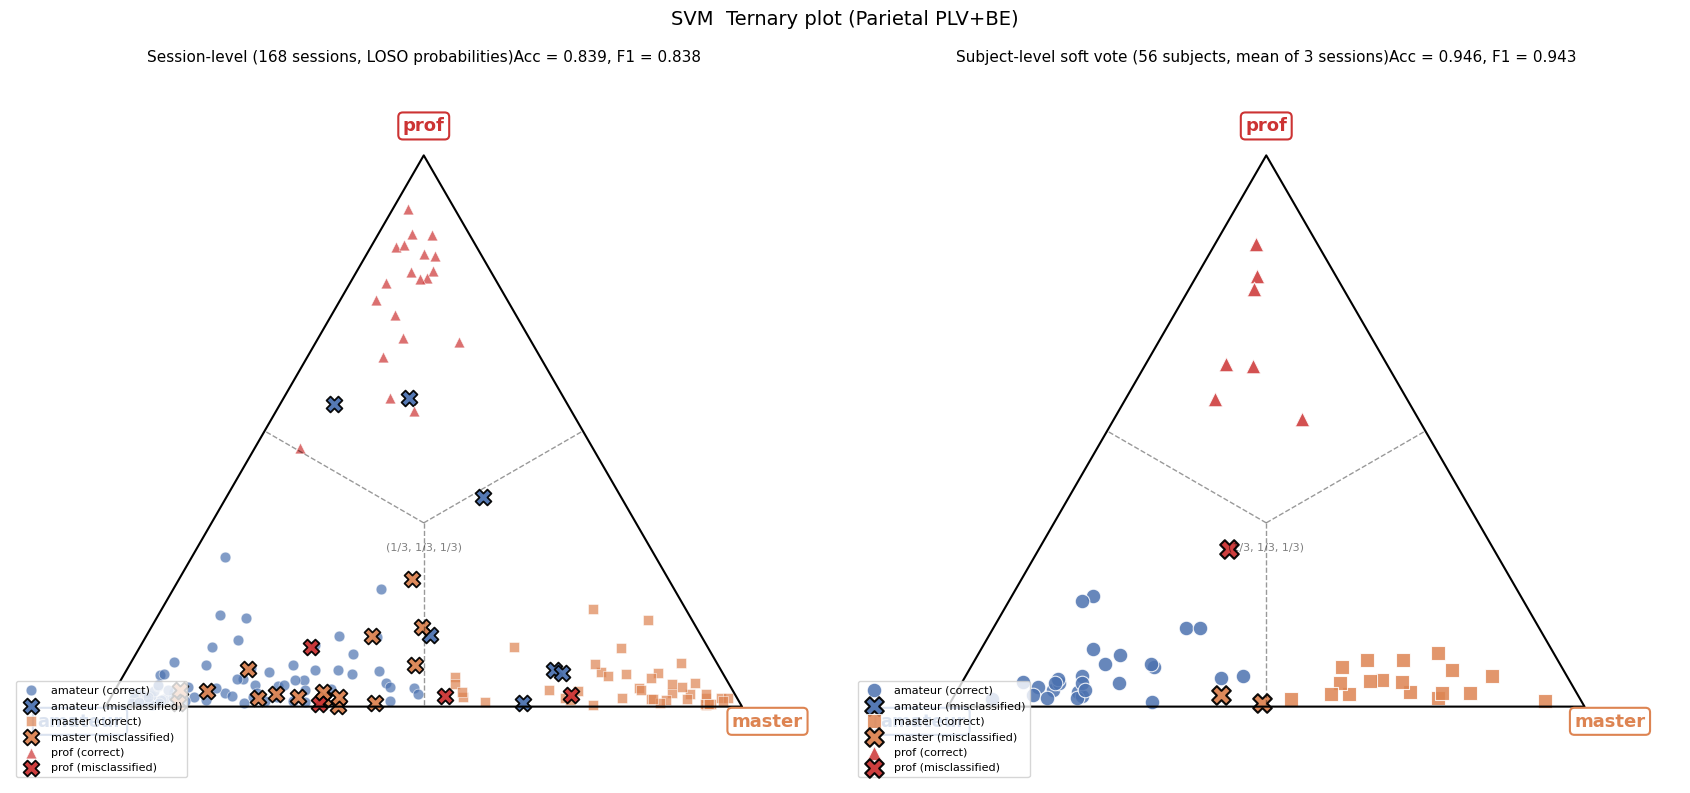

讀圖建議:
  - 點越靠近角落 → SVM 越有信心 (越接近 100% 該類)
  - 點靠近虛線邊界 → SVM 在兩類之間猶豫
  - X 標記的點 = 落在錯誤的 kingdom 區域 → 預測錯誤
  - 比較左右兩圖: 右圖 (subject vote) 的 X 應該明顯變少 (0.946 vs 0.839)


In [104]:
# ── Visualize SVM 的輸出空間：三類機率的 Ternary plot ──
# 每個樣本會被 SVM 給三個機率 (P_amateur + P_master + P_prof = 1) → 落在三角形上某一點
# 角落 = SVM 100% 確信; 中心 = 完全猶豫 (1/3, 1/3, 1/3)
# 三角形被切成三個 "kingdom", 每個區域對應 argmax 預測類別

# 取 LOSO 預測機率 (cell 4 已存的 combined_results)
r_par = combined_results['Parietal']
proba_session = r_par['proba']  # (168, 3) — session-level
y_int = y_all.astype(int)

# Subject-level: 平均 3 個 session 的機率
proba_subject = np.zeros((len(subject_ids), 3))
y_subject = np.zeros(len(subject_ids), dtype=int)
for i, sub_id in enumerate(subject_ids):
    proba_subject[i] = proba_session[i*3:i*3+3].mean(axis=0)
    y_subject[i] = subject_labels[sub_id]

def to_ternary(p):
    """(N, 3) probabilities -> (N, 2) 2D coords. Corners: amateur=(0,0), master=(1,0), prof=(0.5, √3/2)"""
    x = p[:, 1] + p[:, 2] * 0.5
    y = p[:, 2] * np.sqrt(3) / 2
    return np.stack([x, y], axis=1)

corner = {'amateur': np.array([0.0, 0.0]),
          'master':  np.array([1.0, 0.0]),
          'prof':    np.array([0.5, np.sqrt(3)/2])}
center = np.array([0.5, np.sqrt(3)/6])  # 三角形重心 = (1/3, 1/3, 1/3)

def draw_ternary_axes(ax, title):
    # 三角形邊界
    tri = np.vstack([corner['amateur'], corner['master'], corner['prof'], corner['amateur']])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=1.5)
    # SVM argmax 決策邊界 (中心 -> 各邊中點)
    for c1, c2 in [('amateur','master'), ('master','prof'), ('prof','amateur')]:
        mid = (corner[c1] + corner[c2]) / 2
        ax.plot([center[0], mid[0]], [center[1], mid[1]], 'k--', alpha=0.4, lw=1)
    # 角落標籤
    for name, pos in corner.items():
        offset = (pos - center) * 0.08
        ax.text(pos[0] + offset[0], pos[1] + offset[1], name,
                ha='center', va='center', fontsize=13, weight='bold',
                color=group_colors[name],
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=group_colors[name], lw=1.5))
    # 中心點標籤
    ax.text(center[0], center[1] - 0.03, '(1/3, 1/3, 1/3)',
            ha='center', va='top', fontsize=8, alpha=0.5)
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.12, 1.0)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# ─── 左圖: Session-level (168 dots) ───
ax = axes[0]
draw_ternary_axes(ax, f'Session-level (168 sessions, LOSO probabilities)'
                      f'Acc = {r_par["acc"]:.3f}, F1 = {r_par["f1"]:.3f}')
xy_s = to_ternary(proba_session)
preds_s = np.argmax(proba_session, axis=1)
correct_s = (preds_s == y_int)
for g_idx, g in enumerate(CLASS_NAMES):
    mask_g = (y_int == g_idx)
    mask_ok = mask_g & correct_s
    ax.scatter(xy_s[mask_ok, 0], xy_s[mask_ok, 1],
               c=group_colors[g], marker=group_markers[g], s=60, alpha=0.7,
               label=f'{g} (correct)', edgecolors='white', linewidths=0.5)
    mask_bad = mask_g & ~correct_s
    ax.scatter(xy_s[mask_bad, 0], xy_s[mask_bad, 1],
               c=group_colors[g], marker='X', s=130, alpha=0.95,
               edgecolors='black', linewidths=1.3,
               label=f'{g} (misclassified)')
ax.legend(fontsize=8, loc='lower left')

# ─── 右圖: Subject-level soft vote (56 dots) ───
ax = axes[1]
acc_sub = (np.argmax(proba_subject, axis=1) == y_subject).mean()
from sklearn.metrics import f1_score
f1_sub = f1_score(y_subject, np.argmax(proba_subject, axis=1), average='macro', zero_division=0)
draw_ternary_axes(ax, f'Subject-level soft vote (56 subjects, mean of 3 sessions)'
                      f'Acc = {acc_sub:.3f}, F1 = {f1_sub:.3f}')
xy_sub = to_ternary(proba_subject)
preds_sub = np.argmax(proba_subject, axis=1)
correct_sub = (preds_sub == y_subject)
for g_idx, g in enumerate(CLASS_NAMES):
    mask_g = (y_subject == g_idx)
    mask_ok = mask_g & correct_sub
    ax.scatter(xy_sub[mask_ok, 0], xy_sub[mask_ok, 1],
               c=group_colors[g], marker=group_markers[g], s=110, alpha=0.85,
               label=f'{g} (correct)', edgecolors='white', linewidths=0.8)
    mask_bad = mask_g & ~correct_sub
    ax.scatter(xy_sub[mask_bad, 0], xy_sub[mask_bad, 1],
               c=group_colors[g], marker='X', s=180, alpha=0.95,
               edgecolors='black', linewidths=1.5,
               label=f'{g} (misclassified)')
ax.legend(fontsize=8, loc='lower left')

plt.suptitle('SVM  Ternary plot (Parietal PLV+BE)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM_PLV\svm_parietal_ternary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('讀圖建議:')
print('  - 點越靠近角落 → SVM 越有信心 (越接近 100% 該類)')
print('  - 點靠近虛線邊界 → SVM 在兩類之間猶豫')
print('  - X 標記的點 = 落在錯誤的 kingdom 區域 → 預測錯誤')
print('  - 比較左右兩圖: 右圖 (subject vote) 的 X 應該明顯變少 (0.946 vs 0.839)')